## `merged_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `inference.py`

In [71]:
import numpy as np 
import fitsio as fio
import pandas as pd 
import importlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import src.statistics.sgp as sgp

from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from pathlib import Path
from scipy.integrate import simpson
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.calibration as cal

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)
markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}
sigmaj_corr = 1 # temporary

In [230]:
stem = 'v10'
path_dictionary = {
    'HSC' : ROOT / 'v11_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
assert all([p.exists() for p in path_dictionary.values()])

In [231]:
outdir = ROOT / f'merged_{stem}'

In [232]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    #verbose=True,
    #tomo_interest=[1, 2, 3, 4]
    )

Processing redshift bin 0 (Completion : 1.75%)
Processing redshift bin 5 (Completion : 10.53%)
Processing redshift bin 10 (Completion : 19.30%)
Processing redshift bin 15 (Completion : 28.07%)
Processing redshift bin 20 (Completion : 36.84%)
Processing redshift bin 25 (Completion : 45.61%)
Processing redshift bin 30 (Completion : 54.39%)
Processing redshift bin 35 (Completion : 63.16%)
Processing redshift bin 40 (Completion : 71.93%)
Processing redshift bin 45 (Completion : 80.70%)
Processing redshift bin 50 (Completion : 89.47%)
Processing redshift bin 55 (Completion : 98.25%)
It's likely the b1x57_b2x1 estimator has no data for the given redshift bin,
or is not in the tomo bins of interest.
It's likely the b1x57_b2x2 estimator has no data for the given redshift bin,
or is not in the tomo bins of interest.
It's likely the b1x57_b2x3 estimator has no data for the given redshift bin,
or is not in the tomo bins of interest.
It's likely the b1x57_b2x4 estimator has no data for the given r

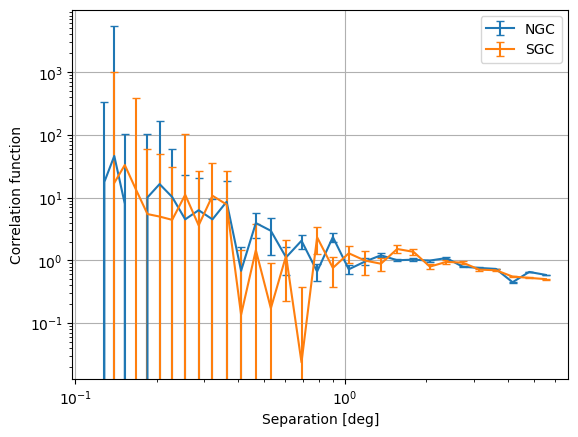

In [233]:
from pycorr import TwoPointEstimator
tgt = 'QSO'  # Target tracer
b = 23
tpcf1 = TwoPointEstimator.load(f'/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/v11_correction/autos_NGC/{tgt}x{tgt}/{tgt}x{tgt}_b1x{b}_b2x{b}_moc1.npy')
tpcf2 = TwoPointEstimator.load(f'/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/v11_correction/autos_SGC/{tgt}x{tgt}/{tgt}x{tgt}_b1x{b}_b2x{b}_moc3.npy')
plt.errorbar(ct.arcsec2hMpc(0.5*(tpcf1.edges[0][1:] + tpcf1.edges[0][:1])*3600, z=2), tpcf1.corr, np.sqrt(np.diag(tpcf1.cov())**2), label='NGC', capsize=3)
plt.errorbar(ct.arcsec2hMpc(0.5*(tpcf2.edges[0][1:] + tpcf2.edges[0][:1])*3600, z=2), tpcf2.corr, np.sqrt(np.diag(tpcf2.cov())**2), label='SGC', capsize=3)
plt.xscale('log')
plt.xlabel('Separation [deg]')
plt.ylabel('Correlation function')
plt.legend()
plt.yscale('log')
plt.grid()

In [234]:
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})

In [245]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    scale_cuts=[1, 5],
    tracer='Merged',
    tomo_bin=4,
    verbose=True,
)
# let's remove NaN values from last bin
print(meas)

Using fine redshift : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05
 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75
 2.8  2.85]
Using merged method for tracer Merged and tomo bin 4.
(array([-7.84748381e-02,  1.02828000e-01,  4.50468149e-01,  6.05164471e-02,
        6.89260163e-02, -1.10209473e-03,  1.77855464e-02,  4.78990701e-03,
       -7.26155756e-03, -2.44334998e-01,  2.49773508e-01,  1.75499449e-02,
        8.69341051e-02, -3.46945319e-02, -7.46079497e-02, -7.70266425e-02,
       -5.45261779e-02,  4.28305526e-02, -5.29785681e-02,  9.89598515e-03,
        2.33994871e-01,  2.79665385e-01,  4.35395459e-01,  8.71298985e-01,
        1.56593029e+00,  2.10665362e+00,  2.41051492e+00,  2.44080560e+00,
        2.18312714e+00,  1.75822074e+00,  1.24266719e+00,  1.00040441e+00,
        6.30193093e-01,  1.

56 56 56
Integrated p(z) = 0.866
Expected p(z) = 1.253


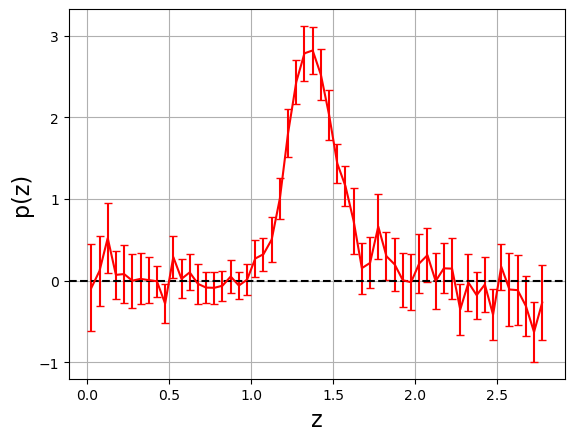

In [246]:
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
zval = (zbins[1:] + zbins[:-1])/2  # we only want the middle values
zval = zval[:-1]  # remove the last value, which is NaN
print(len(zval), len(meas[0]), len(meas[1]))
plt.errorbar(zval, meas[0]/simpson(meas[0], zval), meas[1]/simpson(meas[0], zval), capsize=3, color='red')
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)

print(f'Integrated p(z) = {simpson(meas[0], zval):.3f}')
print(f'Expected p(z) = {simpson(np.multiply(zval, meas[0]/simpson(meas[0], zval)), zval):.3f}')

Using fine redshift : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05
 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75
 2.8  2.85]
Using merged method for tracer Merged and tomo bin 4.
GP kernel: 0.843**2 * Matern(length_scale=0.348, nu=1.5)


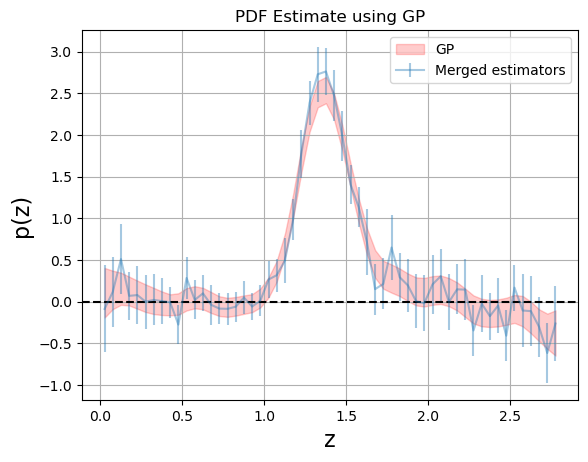

In [247]:
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    scale_cuts=[1, 5],
    tracer='Merged',
    tomo_bin=4,
    verbose=True,
)
zval = (zbins[1:] + zbins[:-1])/2  # we only want the middle values
zval = zval[:-1]  # remove the last value, which is NaN

dz = np.diff(zval)[0]
y = meas[0] / np.sum(meas[0] * dz)
y_err = meas[1] / np.sum(meas[0] * dz)

y_mean, y_std = sgp.gpfit(zval, meas)
plt.errorbar(zval, y, y_err, label='Merged estimators', alpha=0.4)
plt.fill_between(zval, y_mean - y_std, y_mean + y_std, alpha=0.2, label='GP', color='red')
plt.axhline(0, color='k', linestyle='--')
plt.grid(True)
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)
plt.legend()
plt.title('PDF Estimate using GP')
plt.show()

In [248]:
nz = []
nz_err = []
for i in range(1, 21):
    print(f'Processing tomo bin {i}')
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        scale_cuts=[1, 5],
        tracer='Merged',
        tomo_bin=i,
        verbose=True,
    )
    nz.append(meas[0])
    nz_err.append(meas[1])
nz = np.array(nz)
nz_err = np.array(nz_err)

Processing tomo bin 1
Using fine redshift : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05
 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75
 2.8  2.85]
Using merged method for tracer Merged and tomo bin 1.
Processing tomo bin 2
Using fine redshift : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05
 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75
 2.8  2.85]
Using merged method for tracer Merged and tomo bin 2.
Processing tomo bin 3
Using fine redshift : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  

FileNotFoundError: [Errno 2] No such file or directory: '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v10/MergedxHSC/MergedxHSC_b1x1_b2x5.npy'

0.0
0.12
0.24
0.36
0.48
0.6
0.72
0.84
0.96
1.08
1.2
1.3199999999999998
1.44
1.56
1.68
1.7999999999999998
1.92
2.04
2.16
2.28


/tmp/ipykernel_100036/4065999341.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


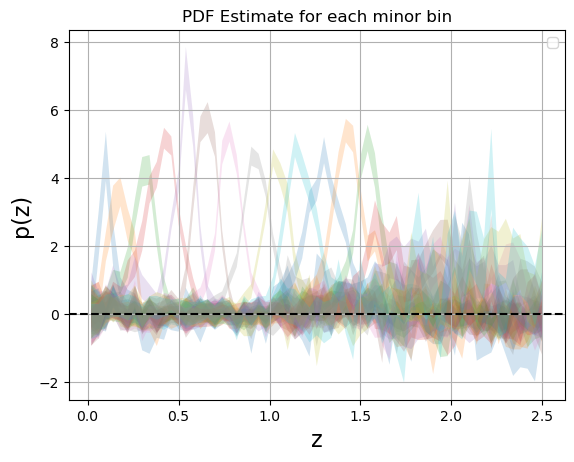

In [125]:
stds = []
for i in range(nz.shape[0]):
    print(i*0.12)
    integrated_nz = simpson(nz[i], zval)
    stds.append(np.std(nz[i]/integrated_nz))
    plt.fill_between(
        zval, 
        (nz[i] - nz_err[i]), 
        (nz[i] + nz_err[i]), 
        alpha=0.2, 
        #label=f'{stds[i]:.2f}', 
    )
plt.grid()
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)
plt.legend()
plt.title('PDF Estimate for each minor bin')
plt.axhline(0, color='k', linestyle='--')

[0.02 0.06 0.1  0.14 0.18 0.22 0.26 0.3  0.34] [0.24921181 2.33826449 4.64456765 2.04862547 0.75455821 0.27748371
 0.23365152 0.         0.        ] [0.68251413 0.66554159 0.72346336 0.6305385  0.32633687 0.4388379
 0.37861012 0.3911697  0.38843604]


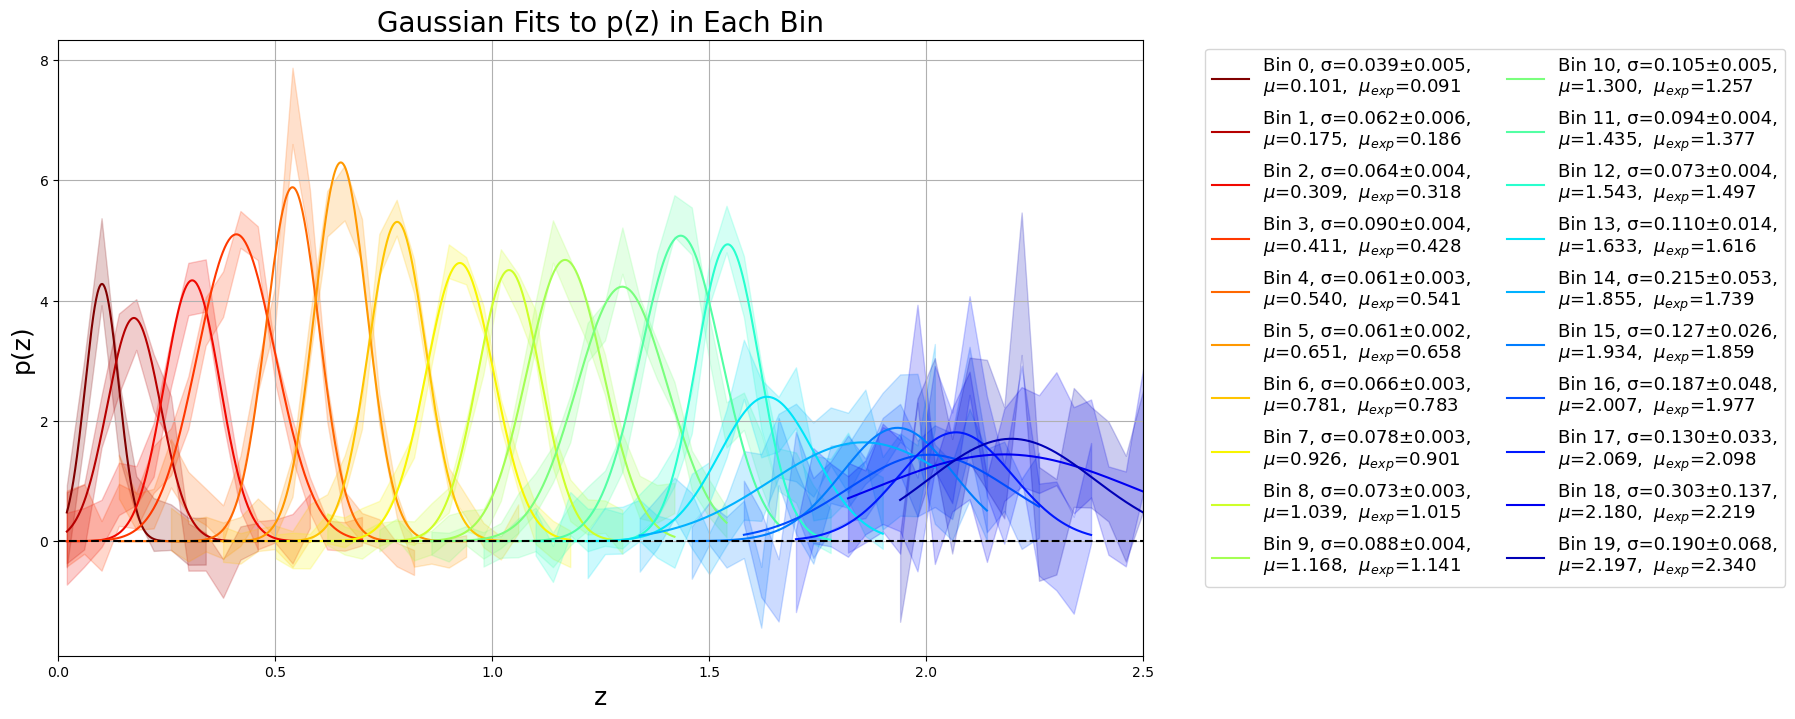

Bin 1: mean = 0.1010, std = 0.0387 ± 0.0052
Bin 2: mean = 0.1746, std = 0.0617 ± 0.0062
Bin 3: mean = 0.3088, std = 0.0640 ± 0.0043
Bin 4: mean = 0.4106, std = 0.0901 ± 0.0042
Bin 5: mean = 0.5400, std = 0.0612 ± 0.0027
Bin 6: mean = 0.6512, std = 0.0610 ± 0.0024
Bin 7: mean = 0.7811, std = 0.0658 ± 0.0025
Bin 8: mean = 0.9256, std = 0.0779 ± 0.0030
Bin 9: mean = 1.0389, std = 0.0731 ± 0.0033
Bin 10: mean = 1.1681, std = 0.0875 ± 0.0039
Bin 11: mean = 1.2999, std = 0.1049 ± 0.0052
Bin 12: mean = 1.4345, std = 0.0936 ± 0.0044
Bin 13: mean = 1.5428, std = 0.0726 ± 0.0043
Bin 14: mean = 1.6333, std = 0.1097 ± 0.0138
Bin 15: mean = 1.8554, std = 0.2153 ± 0.0527
Bin 16: mean = 1.9341, std = 0.1273 ± 0.0263
Bin 17: mean = 2.0068, std = 0.1871 ± 0.0478
Bin 18: mean = 2.0688, std = 0.1303 ± 0.0327
Bin 19: mean = 2.1799, std = 0.3030 ± 0.1367
Bin 20: mean = 2.1967, std = 0.1903 ± 0.0681


In [205]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import simpson
cmap = plt.get_cmap('jet_r')

# Gaussian model
def gaussian(z, A, mu, sigma):
    return A * np.exp(-0.5 * ((z - mu) / sigma)**2)

means = []
stds = []
stds_err = []  # <-- store std errors

plt.figure(figsize=(14, 8))

for i in range(nz.shape[0]):
    mask = ~np.isnan(nz[i]) & (zval >= (i-3)*0.12) & (zval <= (i+3)*0.12)  # Mask NaN values and restrict to z range
    z = zval[mask]
    y = nz[i][mask]
    yerr = nz_err[i][mask]
    
    if i == 0:
        y = np.maximum(y, 0)  # clean up negatives
        print(z, y, yerr)

    # Initial guess
    A0 = np.max(y)
    mu0 = np.sum(z * y) / np.sum(y)
    sigma0 = np.sqrt(np.sum(y * (z - mu0)**2) / np.sum(y))

    try:
        popt, pcov = curve_fit(
            gaussian, z, y, p0=[A0, mu0, sigma0], sigma=yerr, absolute_sigma=True
        )
        A_fit, mu_fit, sigma_fit = popt
        sigma_fit_err = np.sqrt(pcov[2, 2])  # <-- get std error

        # Store results
        means.append(mu_fit)
        stds.append(sigma_fit)
        stds_err.append(sigma_fit_err)  # <-- store std error

        zfit = np.linspace(z.min(), z.max(), 300)
        color = cmap(i / nz.shape[0])  # Use colormap for color cycling
        plt.plot(
            zfit, 
            gaussian(zfit, *popt), 
            label=(
                f'Bin {i}, σ={sigma_fit:.3f}±{sigma_fit_err:.3f},\n' 
                + r'$\mu$' 
                + f'={mu_fit:.3f},  ' 
                + r'$\mu_{exp}$'
                + f'={zeff[i]:.3f}'
            ), 
            color=color
        )
        plt.fill_between(z, y - yerr, y + yerr, alpha=0.2, color=color)

    except RuntimeError:
        print(f"Fit failed for bin {i}")
        means.append(np.nan)
        stds.append(np.nan)
        stds_err.append(np.nan)

plt.grid()
plt.xlabel('z', fontsize=18)
plt.ylabel('p(z)', fontsize=18)
plt.title('Gaussian Fits to p(z) in Each Bin', fontsize=20)
plt.axhline(0, color='k', linestyle='--')
plt.legend(ncols=2, fontsize=13, loc='upper right', bbox_to_anchor=(1.6, 1.0))
plt.xlim(0, 2.5)
plt.show()

# Final results
for i, (m, s, s_err) in enumerate(zip(means, stds, stds_err)):
    print(f"Bin {i+1}: mean = {m:.4f}, std = {s:.4f} ± {s_err:.4f}")

Bin 0: mean = 0.1010, std = 0.0387
Effective redshift for DESI from 0.0 to 0.12: 0.0909
Bin 1: mean = 0.1746, std = 0.0617
Effective redshift for DESI from 0.12 to 0.24: 0.1858
Bin 2: mean = 0.3088, std = 0.0640
Effective redshift for DESI from 0.24 to 0.36: 0.3184
Bin 3: mean = 0.4106, std = 0.0901
Effective redshift for DESI from 0.36 to 0.48: 0.4277
Bin 4: mean = 0.5400, std = 0.0612
Effective redshift for DESI from 0.48 to 0.6: 0.5409
Bin 5: mean = 0.6512, std = 0.0610
Effective redshift for DESI from 0.6 to 0.72: 0.6582
Bin 6: mean = 0.7811, std = 0.0658
Effective redshift for DESI from 0.72 to 0.84: 0.7832
Bin 7: mean = 0.9256, std = 0.0779
Effective redshift for DESI from 0.84 to 0.96: 0.9010
Bin 8: mean = 1.0389, std = 0.0731
Effective redshift for DESI from 0.96 to 1.08: 1.0154
Bin 9: mean = 1.1681, std = 0.0875
Effective redshift for DESI from 1.08 to 1.2: 1.1412
Bin 10: mean = 1.2999, std = 0.1049
Effective redshift for DESI from 1.2 to 1.3199999999999998: 1.2566
Bin 11: mea

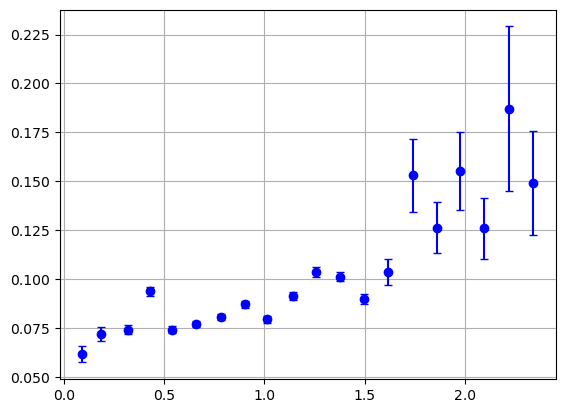

In [213]:
importlib.reload(inference)
importlib.reload(comb)
wpp = []
zeff = []
for i in range(20):
    print(f'Bin {i}: mean = {means[i]:.4f}, std = {stds[i]:.4f}')
    ## now let's get the wpp measurements to get the full correction
    wpp_meas, wpp_err, _ = inference.wpp(
            path=path_dictionary['HSC'],
            scale_cuts=[1, 5],
            bin_index=i+1,
        )
    wpp.append(wpp_meas)
    zeff.append(cf.get_zeff(zlow=i*0.12, zhigh=(i+1)*0.12, type='HSC'))
errs = comb.combine_error_bars_mult(wpp, wpp_err, stds, stds_err)
vals = np.sqrt(np.array(wpp)*np.array(stds))
#plt.plot(means, np.sqrt(np.array(wpp)*np.array(stds)), label='wpp')
plt.errorbar(zeff, vals, errs, label='wpp', capsize=3, fmt='o', color='blue')
plt.grid()


Fitted power law:
  a = 0.06413057079454319 ± 0.0014342952459698232
  gamma = 0.4539423871141212 ± 0.03450372293660535


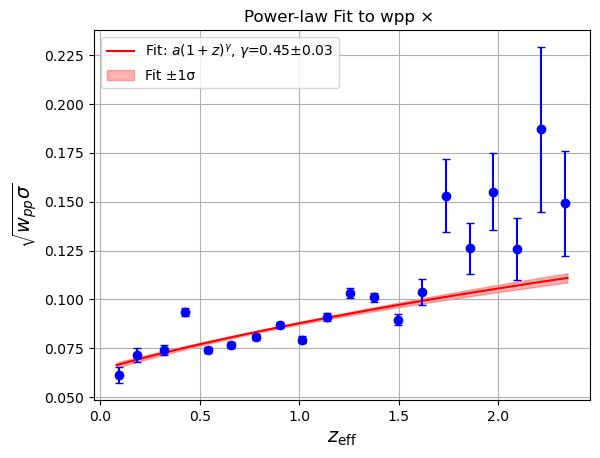

In [214]:
from scipy.optimize import curve_fit

def power_law(z, a, gamma):
    return a * (1 + z)**gamma

# Var(f) ≈ (df/da)^2 * Var(a) + (df/dγ)^2 * Var(γ) + 2*Cov(a,γ)*df/da*df/dγ
def power_law_error(z, a, gamma, pcov):
    da = (1 + z)**gamma
    dgamma = a * (1 + z)**gamma * np.log(1 + z)
    var = (
        da**2 * pcov[0, 0] +
        dgamma**2 * pcov[1, 1] +
        2 * da * dgamma * pcov[0, 1]
    )
    return np.sqrt(var)

zeff_arr = np.array(zeff)
vals_arr = np.array(vals)
errs_arr = np.array(errs)

p0 = [np.mean(vals_arr), 1.0]

popt, pcov = curve_fit(
    power_law, zeff_arr, vals_arr, p0=p0, sigma=errs_arr, absolute_sigma=True
)
a_fit, gamma_fit = popt
a_err, gamma_err = np.sqrt(np.diag(pcov))

print(f"\nFitted power law:\n  a = {a_fit} ± {a_err}\n  gamma = {gamma_fit} ± {gamma_err}")

# Create fit curve and error band
z_plot = np.linspace(min(zeff_arr)-0.01, max(zeff_arr)+0.01, 300)
fit_vals = power_law(z_plot, a_fit, gamma_fit)

fit_errs = power_law_error(z_plot, a_fit, gamma_fit, pcov)

plt.plot(z_plot, fit_vals, 'r-', label=fr'Fit: $a(1+z)^{{\gamma}}$, $\gamma$={gamma_fit:.2f}±{gamma_err:.2f}')
plt.fill_between(z_plot, fit_vals - fit_errs, fit_vals + fit_errs, color='red', alpha=0.3, label='Fit ±1σ')

plt.legend()
plt.ylabel(r'$\sqrt{w_{pp}\sigma}$', fontsize=14)
plt.errorbar(zeff, vals, errs, label='wpp', capsize=3, fmt='o', color='blue')
plt.xlabel(r'$z_{\rm eff}$', fontsize=14)
plt.title('Power-law Fit to wpp × ')
plt.grid()
plt.show()

zeff = [0.0347693  0.07759296 0.12665131 0.17575151 0.22482497 0.27404603
 0.32393083 0.37330081 0.42347698 0.47350585 0.52557593 0.57538912
 0.62527369 0.67527805 0.72542612 0.7758609  0.82548476 0.87483143
 0.92488506 0.9743975  1.02408659 1.07442255 1.12495753 1.1749018
 1.22475909 1.27483098 1.32495408 1.3747339  1.42491349 1.47396121
 1.52443496 1.57456234 1.62520736 1.6749617  1.72500914 1.77491857
 1.82501929 1.87496822 1.92492935 1.97466114 2.02475569 2.074603
 2.12482457 2.17456537 2.22471904 2.27458471 2.3243192  2.37479401
 2.42459292 2.47467053 2.52491472 2.57436009 2.62482698 2.67448626
 2.72458    2.77455367 2.82498659]
Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Tomo 1 :
0.47156892218899826
0.1322711407228443

Tomo 2 :
0.7620892412300715
0.6117840308005627

Tomo 3 :
1.063348605954003
1.0372398319797127

(-1.2, 4.4)

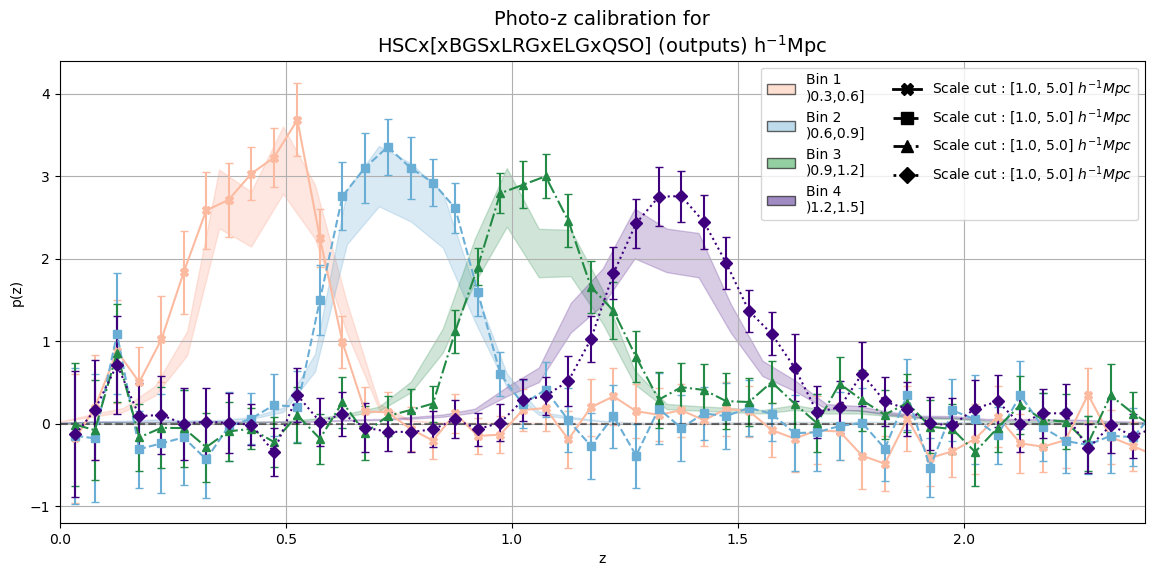

In [251]:
importlib.reload(inference)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

scale_cut = [1, 5]  # scale cuts for the analysis

tomo_interest = [1, 2, 3, 4]  # tomographic bins of interest
title = 'Photo-z calibration for\nHSCx['
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
redshifts = np.load('zeff/desi_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(redshifts[(zbins[i] < redshifts) & (redshifts <= zbins[i+1])]) for i in range(len(zbins)-1)]
)
print(f'zeff = {zeff}')
zeff = zeff[:-1]

nz = []
nz_err = []
for tomo in tomo_interest:
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    nonnanz = ~np.isnan(tomo_nz)
    tomo_nz = tomo_nz[nonnanz]
    tomo_nz_err = tomo_nz_err[nonnanz]
    zval = zeff[nonnanz]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)
    ax.errorbar(
        x=zval, 
        y=nz[tomo-1],
        yerr=nz_err[tomo-1],#/normalization, 
        capsize=3,
        marker=markers[tomo-1], 
        linestyle=linestyles[tomo-1],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo-1]((tomo)/4),
        )
        
    title+= f'x{tracer_trad[tracers[tomo-1]]}'

mids = tomo_bin_dnnz[:, 0]
mask_mids = mids < 2.725

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(0, 4):
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
        alpha=0.2
        )
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in tomo_interest:
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

for i in range(len(nz)):
    print(f'Tomo {i+1} :')
    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.4)
ax.set_ylim(-1.2, 4.4)

## Gaussian Process Models

zeff = [0.0347693  0.07759296 0.12665131 0.17575151 0.22482497 0.27404603
 0.32393083 0.37330081 0.42347698 0.47350585 0.52557593 0.57538912
 0.62527369 0.67527805 0.72542612 0.7758609  0.82548476 0.87483143
 0.92488506 0.9743975  1.02408659 1.07442255 1.12495753 1.1749018
 1.22475909 1.27483098 1.32495408 1.3747339  1.42491349 1.47396121
 1.52443496 1.57456234 1.62520736 1.6749617  1.72500914 1.77491857
 1.82501929 1.87496822 1.92492935 1.97466114 2.02475569 2.074603
 2.12482457 2.17456537 2.22471904 2.27458471 2.3243192  2.37479401]
Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Tomo 1 :
0.4711478934264351
0.2648992922811123

Tomo 2 :
0.763346695316163
0.7122804028496817

Tomo 3 :
1.0627614644012675
1.1632774479780645

Tomo 4 :
1.3016591702621905
1.377377787940574



(-1.2, 4.5)

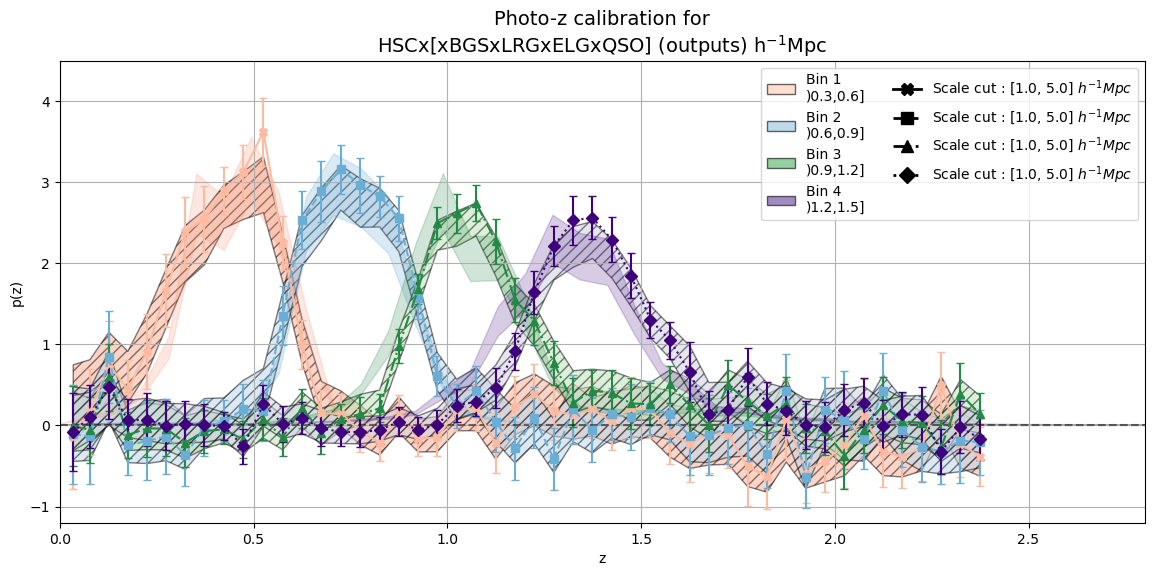

In [ ]:
importlib.reload(inference)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

scale_cut = [1, 5]

tomo_interest = [1, 2, 3, 4]  # tomographic bins of interest
title = 'Photo-z calibration for\nHSCx['
zbins = np.arange(0.0, 2.4 + 0.05, 0.05)
redshifts = np.load('zeff/desi_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(redshifts[(zbins[i] < redshifts) & (redshifts <= zbins[i+1])]) for i in range(len(zbins)-1)]
)
print(f'zeff = {zeff}')

nz = []
nz_err = []
for tomo in tomo_interest:
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    nonnanz = ~np.isnan(tomo_nz)
    tomo_nz = tomo_nz[nonnanz]
    tomo_nz_err = tomo_nz_err[nonnanz]
    zval = zeff[nonnanz]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)

    dz = np.diff(zval)[0]
    y = nz[-1]
    y_err = nz_err[-1]

    X = zval.reshape(-1, 1)
    kernel = ConstantKernel(1.0) * Matern(nu=1.5)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=(y_err**2), n_restarts_optimizer=10)

    assert np.all(np.isfinite(X))
    assert np.all(np.isfinite(y))
    assert np.all(np.isfinite(y_err))
    assert X.shape == (len(y), 1)

    gp.fit(X, y)

    y_mean, y_std = gp.predict(X, return_std=True)

    ax.fill_between(
        zval,
        y_mean - y_std,
        y_mean + y_std,
        alpha=0.5,
        color=colormaps[tomo-1](0.3),
        edgecolor='black',
        label=f'{tracer_trad[tracers[tomo-1]]} (GP)',
        hatch='///'
    )

    ax.errorbar(
        x=zval, 
        y=nz[tomo-1],
        yerr=nz_err[tomo-1],#/normalization, 
        capsize=3,
        marker=markers[tomo-1], 
        linestyle=linestyles[tomo-1],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo-1]((tomo)/4),
        )
        
    title+= f'x{tracer_trad[tracers[tomo-1]]}'

mids = tomo_bin_dnnz[:, 0]
mask_mids = mids < 2.725

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(0, 4):
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
        alpha=0.2
        )
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in tomo_interest:
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

for i in range(len(nz)):
    print(f'Tomo {i+1} :')
    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.8)
ax.set_ylim(-1.2, 4.5)

Magnification bias corrections :
$ w_{sp}(z_i) = n_p(z_i) b_p(z_i) b_s(z_i) w_{\mathrm{DM}}(z_i) + 
b_s(z_i) \alpha_p(z_i) \sum_{j>i} \left[ D_{ij} n_p(z_j) \right] + 
b_p(z_i) \alpha_s(z_i) \sum_{j>i} \left[ D_{ij} n_p(z_i) \right] $  

$ \frac{w_{sp}(z_i)}{\Delta z\sqrt{w_{pp}(z_i)w_{ss}(z_i)}} = n_p(z_i) + 
\frac{\alpha_p(z_i)}{b_p(z_i)} \sum_{j>i} \left[ D_{ij}^n n_p(z_j) \right] + 
\frac{\alpha_s(z_i)}{b_s(z_i)} \sum_{j>i} \left[ D_{ij}^n n_p(z_i) \right] $  

$ D_{ij}^n = \frac{D_{ij}}{w_{\mathrm{DM}}(z_i)} $  

$ D_{ij} = \frac{3 H_0^2 \Omega_m}{c^2} w_{\mathrm{DM}}(z_i)
\frac{\chi(z_j)\left[ \chi(z_j) - \chi(z_i) \right]}{a(z_i) \chi(z_j)} \Delta \chi_j $  

In [ ]:
import cosmotools as ct
ct.cosmo.a

AttributeError: 'FlatLambdaCDM' object has no attribute 'c'

### Gaussian Mixture

XDGMM fitted with 3 components
LogL: -739.49


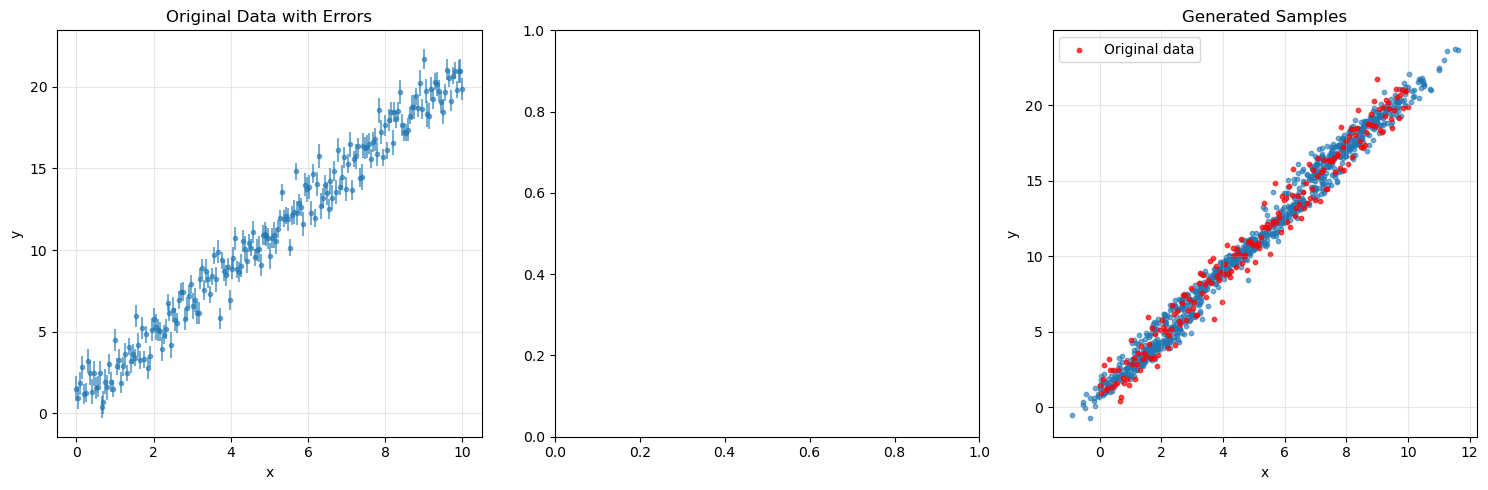

Components: 1, Log-likelihood: -765.57
Components: 2, Log-likelihood: -750.23
Components: 3, Log-likelihood: -739.49
Components: 4, Log-likelihood: -733.39
Components: 5, Log-likelihood: -729.89


/global/homes/j/jeanchdj/.conda/envs/desi/lib/python3.11/site-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Components: 6, Log-likelihood: -727.93


/global/homes/j/jeanchdj/.conda/envs/desi/lib/python3.11/site-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Components: 7, Log-likelihood: -725.19


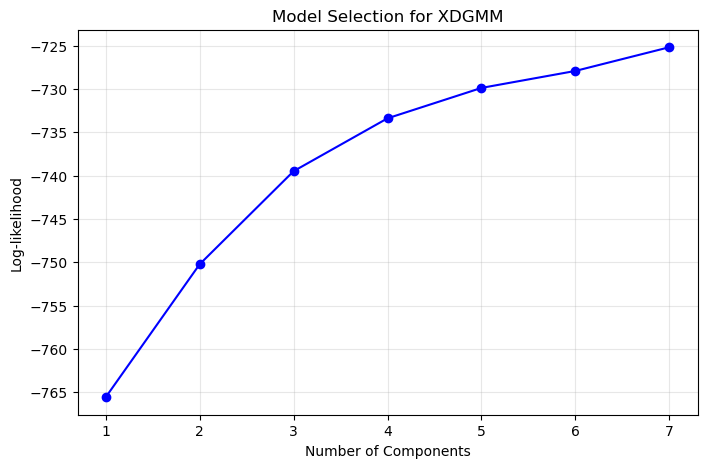

Best number of components: 7


In [ ]:
import numpy as np
from astroML.density_estimation import XDGMM
import matplotlib.pyplot as plt

# Assuming you have your data arrays: x, y, y_err
# Example data (replace with your actual arrays)
np.random.seed(42)
n_points = 200
x = np.linspace(0, 10, n_points)
y = 2 * x + 1 + np.random.normal(0, 1, n_points)
y_err = 0.5 + 0.3 * np.random.random(n_points)

# Step 1: Prepare the data for XDGMM
# XDGMM expects data in shape (n_samples, n_features)
X = np.column_stack([x, y])

# Step 2: Prepare the covariance matrices
# For each data point, create a 2x2 covariance matrix
# Assuming no correlation between x and y errors, and x has no error
n_samples = len(x)
Xerr = np.zeros((n_samples, 2, 2))

for i in range(n_samples):
    # Diagonal covariance matrix
    # Assuming x has negligible error (you can modify this)
    x_err = 0.01  # Small error for x
    Xerr[i] = np.diag([x_err**2, y_err[i]**2])

# Step 3: Create and fit the XDGMM model
n_components = 3  # Number of Gaussian components (adjust as needed)
xdgmm = XDGMM(n_components=n_components, max_iter=100)

# Fit the model
xdgmm.fit(X, Xerr)

print(f"XDGMM fitted with {n_components} components")
print(f"LogL: {xdgmm.logL(X, Xerr):.2f}")

# Step 4: Generate samples from the fitted model
n_samples_generate = 1000
X_sample = xdgmm.sample(n_samples_generate)

# Step 5: Evaluate the model at specific points
# Create a grid for evaluation
x_grid = np.linspace(x.min(), x.max(), 50)
y_grid = np.linspace(y.min(), y.max(), 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

# This section was replaced with sample-based density estimation above

# Step 6: Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Original data with error bars
axes[0].errorbar(x, y, yerr=y_err, fmt='o', alpha=0.6, markersize=3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Original Data with Errors')
axes[0].grid(True, alpha=0.3)


# Plot 3: Generated samples
axes[2].scatter(X_sample[:, 0], X_sample[:, 1], alpha=0.6, s=10)
axes[2].scatter(x, y, c='red', s=10, alpha=0.7, label='Original data')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Generated Samples')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 7: Model selection (optional)
# You can try different numbers of components and use information criteria
from sklearn.model_selection import cross_val_score

def fit_xdgmm_components(n_comp):
    """Helper function to fit XDGMM with n_comp components"""
    model = XDGMM(n_components=n_comp, max_iter=100)
    model.fit(X, Xerr)
    return model.logL(X, Xerr)

# Test different numbers of components
n_components_range = range(1, 4)
log_likelihoods = []

for n_comp in n_components_range:
    ll = fit_xdgmm_components(n_comp)
    log_likelihoods.append(ll)
    print(f"Components: {n_comp}, Log-likelihood: {ll:.2f}")

# Plot model selection
plt.figure(figsize=(8, 5))
plt.plot(n_components_range, log_likelihoods, 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Log-likelihood')
plt.title('Model Selection for XDGMM')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best number of components: {n_components_range[np.argmax(log_likelihoods)]}")

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

def fit_gmm_1d(X, n_components=2):
    """
    Fit Gaussian Mixture Model to 1D data to decompose histogram
    
    Parameters:
    X: array-like, shape (n_samples,) - your 1D data
    n_components: int, number of Gaussian components to find
    
    Returns:
    dict with GMM results including individual Gaussian parameters
    """
    # Reshape for sklearn (needs 2D input)
    X_reshaped = X.reshape(-1, 1)
    
    # Fit GMM
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X_reshaped)
    
    # Extract 1D parameters
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_
    
    # Get predictions
    labels = gmm.predict(X_reshaped)
    probabilities = gmm.predict_proba(X_reshaped)
    
    return {
        'model': gmm,
        'labels': labels,
        'probabilities': probabilities,
        'means': means,
        'stds': stds,
        'weights': weights,
        'aic': gmm.aic(X_reshaped),
        'bic': gmm.bic(X_reshaped),
        'log_likelihood': gmm.score(X_reshaped)
    }

def plot_histogram_decomposition(X, results, title="Histogram Decomposition", bins=50):
    """Plot histogram with overlaid Gaussian components"""
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Histogram with total fit
    plt.subplot(2, 2, 1)
    
    # Plot histogram
    counts, bin_edges, _ = plt.hist(X, bins=bins, density=True, alpha=0.7, 
                                   color='lightblue', edgecolor='black')
    
    # Create smooth x range for plotting curves
    x_range = np.linspace(X.min(), X.max(), 1000)
    
    # Plot total mixture
    total_pdf = np.zeros_like(x_range)
    for i in range(len(results['weights'])):
        component_pdf = results['weights'][i] * norm.pdf(x_range, 
                                                        results['means'][i], 
                                                        results['stds'][i])
        total_pdf += component_pdf
    
    plt.plot(x_range, total_pdf, 'r-', linewidth=3, label='Total GMM Fit')
    plt.title(f'{title} - Histogram + Total Fit')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Individual Gaussian components
    plt.subplot(2, 2, 2)
    
    # Plot histogram (lighter)
    plt.hist(X, bins=bins, density=True, alpha=0.3, color='lightgray', edgecolor='black')
    
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink']
    
    # Plot each component
    for i in range(len(results['weights'])):
        component_pdf = results['weights'][i] * norm.pdf(x_range, 
                                                        results['means'][i], 
                                                        results['stds'][i])
        plt.plot(x_range, component_pdf, color=colors[i % len(colors)], 
                linewidth=2, label=f'Component {i+1}')
        
        # Mark the mean
        plt.axvline(results['means'][i], color=colors[i % len(colors)], 
                   linestyle='--', alpha=0.7)
    
    # Plot total mixture
    plt.plot(x_range, total_pdf, 'k-', linewidth=3, label='Total Mixture')
    
    plt.title(f'{title} - Individual Components')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Component assignments
    plt.subplot(2, 2, 3)
    
    for i in range(len(results['weights'])):
        mask = results['labels'] == i
        plt.hist(X[mask], bins=bins//2, density=True, alpha=0.7, 
                color=colors[i % len(colors)], label=f'Component {i+1}')
    
    plt.title('Data Points by Component')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Residuals
    plt.subplot(2, 2, 4)
    
    # Calculate residuals
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    fitted_values = np.zeros_like(bin_centers)
    
    for center in bin_centers:
        for i in range(len(results['weights'])):
            fitted_values += results['weights'][i] * norm.pdf(center, 
                                                            results['means'][i], 
                                                            results['stds'][i])
    
    # Interpolate histogram to same points
    hist_interp = np.interp(bin_centers, bin_centers, counts)
    residuals = hist_interp - fitted_values
    
    plt.plot(bin_centers, residuals, 'bo-', alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals (Histogram - Fit)')
    plt.xlabel('Value')
    plt.ylabel('Residual')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def print_component_summary(results):
    """Print summary of each Gaussian component"""
    n_components = len(results['weights'])
    
    print("=== Gaussian Components Summary ===")
    print(f"Number of components: {n_components}")
    print(f"Log-likelihood: {results['log_likelihood']:.3f}")
    print(f"AIC: {results['aic']:.3f}")
    print(f"BIC: {results['bic']:.3f}")
    print()
    
    for i in range(n_components):
        print(f"Component {i+1}:")
        print(f"  Weight (mixing coefficient): {results['weights'][i]:.3f}")
        print(f"  Mean (μ): {results['means'][i]:.3f}")
        print(f"  Standard deviation (σ): {results['stds'][i]:.3f}")
        print(f"  Contribution: {results['weights'][i]*100:.1f}% of total distribution")
        print()

def find_optimal_components(X, max_components=10):
    """Find optimal number of components using AIC and BIC"""
    X_reshaped = X.reshape(-1, 1)
    
    n_components_range = range(1, max_components + 1)
    aic_scores = []
    bic_scores = []
    
    for n in n_components_range:
        gmm = GaussianMixture(n_components=n, random_state=42)
        gmm.fit(X_reshaped)
        aic_scores.append(gmm.aic(X_reshaped))
        bic_scores.append(gmm.bic(X_reshaped))
    
    # Plot results
    plt.figure(figsize=(10, 5))
    plt.plot(n_components_range, aic_scores, 'bo-', label='AIC')
    plt.plot(n_components_range, bic_scores, 'ro-', label='BIC')
    plt.xlabel('Number of Components')
    plt.ylabel('Information Criterion')
    plt.title('Model Selection: AIC vs BIC')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Find optimal
    optimal_aic = n_components_range[np.argmin(aic_scores)]
    optimal_bic = n_components_range[np.argmin(bic_scores)]
    
    print(f"Optimal components (AIC): {optimal_aic}")
    print(f"Optimal components (BIC): {optimal_bic}")
    
    return optimal_aic, optimal_bic

def generate_sample_data():
    """Generate sample multimodal data for demonstration"""
    np.random.seed(42)
    
    # Create a mixture of 3 Gaussians
    component1 = np.random.normal(-2, 0.8, 400)   # Left peak
    component2 = np.random.normal(1, 1.2, 600)    # Middle peak  
    component3 = np.random.normal(4, 0.6, 300)    # Right peak
    
    # Combine all components
    X = np.concatenate([component1, component2, component3])
    
    return X

Analyzing 1D distribution...
Data shape: (48,)
Data range: [-0.63, 3.62]

Finding optimal number of components...


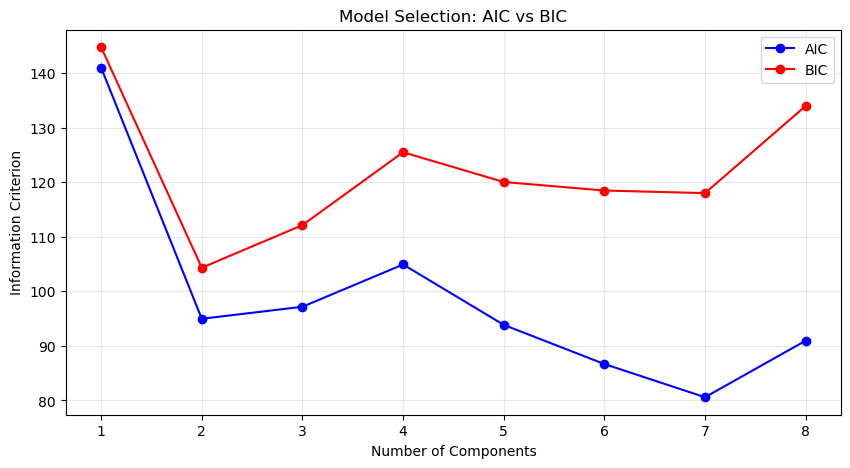

Optimal components (AIC): 7
Optimal components (BIC): 2

=== Gaussian Components Summary ===
Number of components: 2
Log-likelihood: -0.885
AIC: 94.979
BIC: 104.335

Component 1:
  Weight (mixing coefficient): 0.849
  Mean (μ): 0.016
  Standard deviation (σ): 0.355
  Contribution: 84.9% of total distribution

Component 2:
  Weight (mixing coefficient): 0.151
  Mean (μ): 2.582
  Standard deviation (σ): 0.658
  Contribution: 15.1% of total distribution



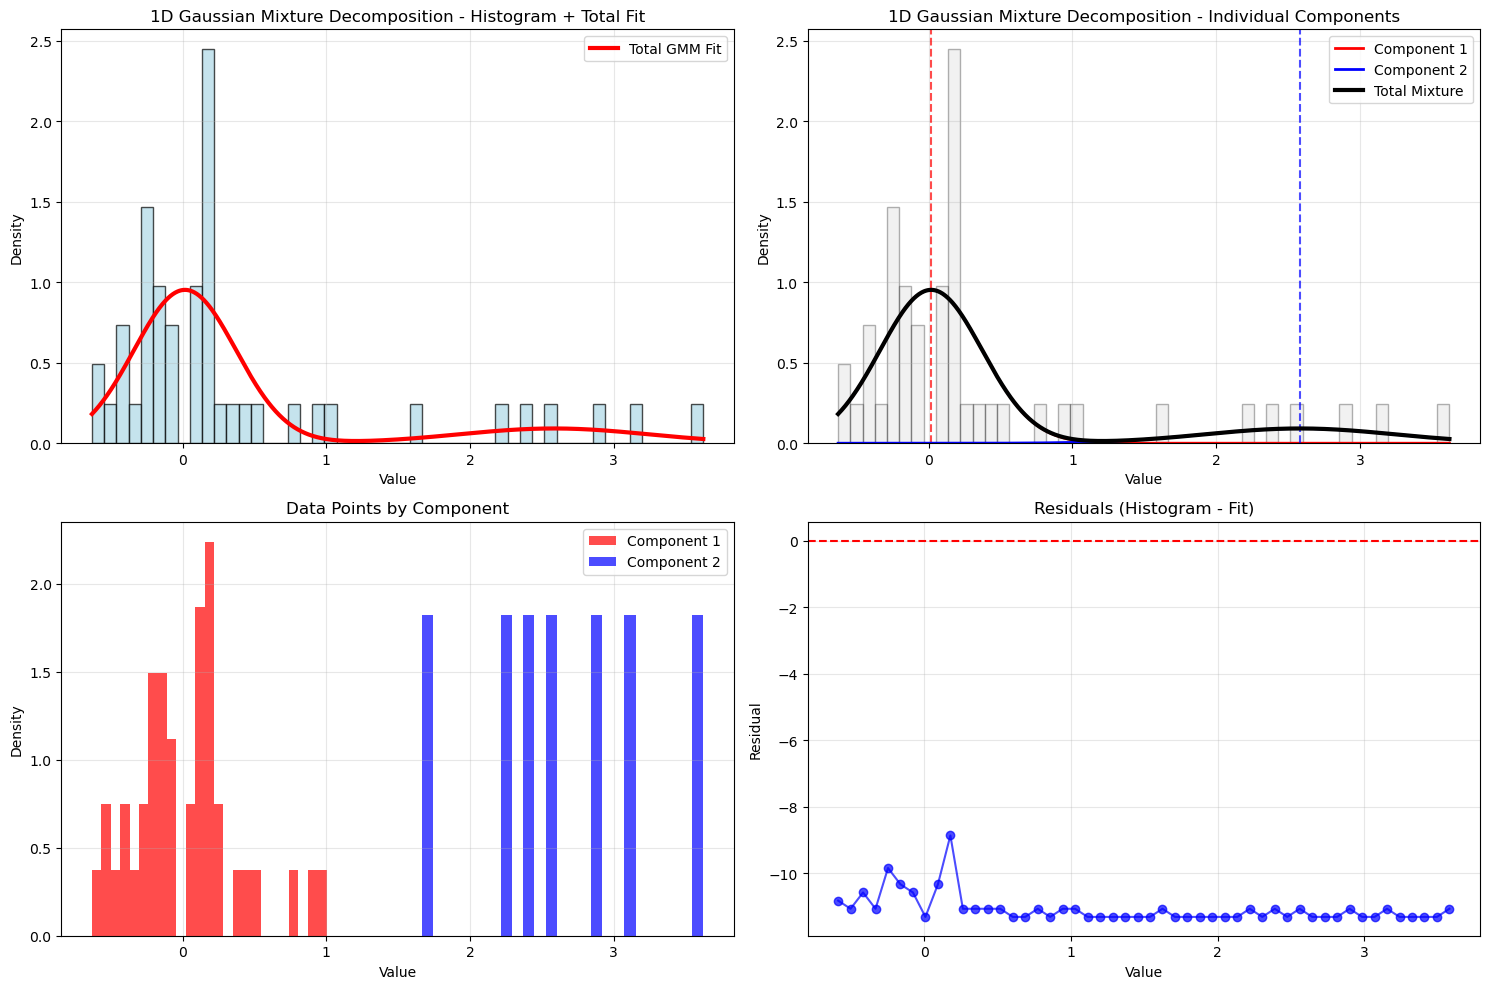

=== How to use results ===
Component means: [0.01640508 2.58244655]
Component standard deviations: [0.35549772 0.65753434]
Component weights: [0.84894706 0.15105294]

To recreate any component:
Component 1: weight=0.849 * Normal(μ=0.016, σ=0.355)
Component 2: weight=0.151 * Normal(μ=2.582, σ=0.658)


In [78]:
# Generate or load your data
X = np.array(nz[0])

print("Analyzing 1D distribution...")
print(f"Data shape: {X.shape}")
print(f"Data range: [{X.min():.2f}, {X.max():.2f}]")
print()

# Find optimal number of components
print("Finding optimal number of components...")
optimal_aic, optimal_bic = find_optimal_components(X, max_components=8)
print()

# Fit GMM with optimal number of components
n_components = 2  # You can change this or use optimal_bic
results = fit_gmm_1d(X, n_components=n_components)

# Print component details
print_component_summary(results)

# Plot decomposition
plot_histogram_decomposition(X, results, "1D Gaussian Mixture Decomposition")

# Show how to use results
print("=== How to use results ===")
print("Component means:", results['means'])
print("Component standard deviations:", results['stds'])
print("Component weights:", results['weights'])
print()
print("To recreate any component:")
for i in range(len(results['weights'])):
    print(f"Component {i+1}: weight={results['weights'][i]:.3f} * Normal(μ={results['means'][i]:.3f}, σ={results['stds'][i]:.3f})")

Example with your X and Y arrays:
X shape: (48,)
Y shape: (48,)



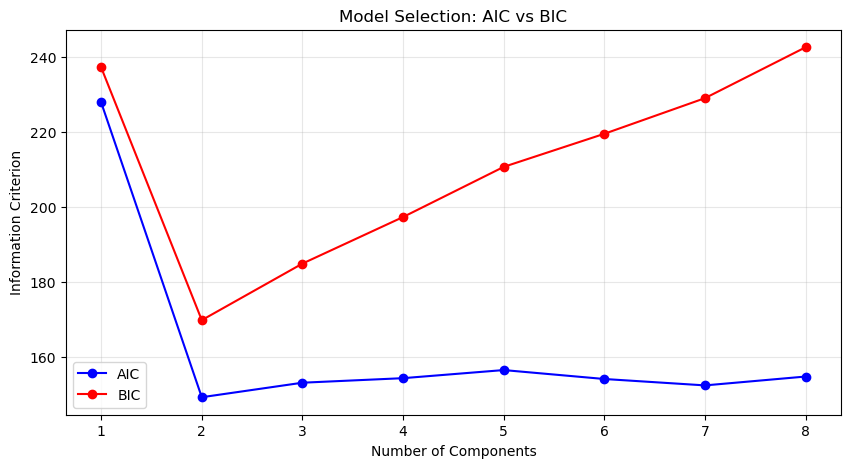

Optimal components (AIC): 2
Optimal components (BIC): 2
=== GMM Results Summary ===
Number of components: 3
Log-likelihood: -1.241
AIC: 153.105
BIC: 184.915

Component 1:
  Weight: 0.301
  Mean: [-0.239, 2.027]
  Covariance:
    [[0.081, 0.013],
     [0.013, 0.050]]

Component 2:
  Weight: 0.249
  Mean: [1.725, 0.302]
  Covariance:
    [[1.457, 0.189],
     [0.189, 0.029]]

Component 3:
  Weight: 0.451
  Mean: [0.105, 1.144]
  Covariance:
    [[0.071, -0.023],
     [-0.023, 0.109]]



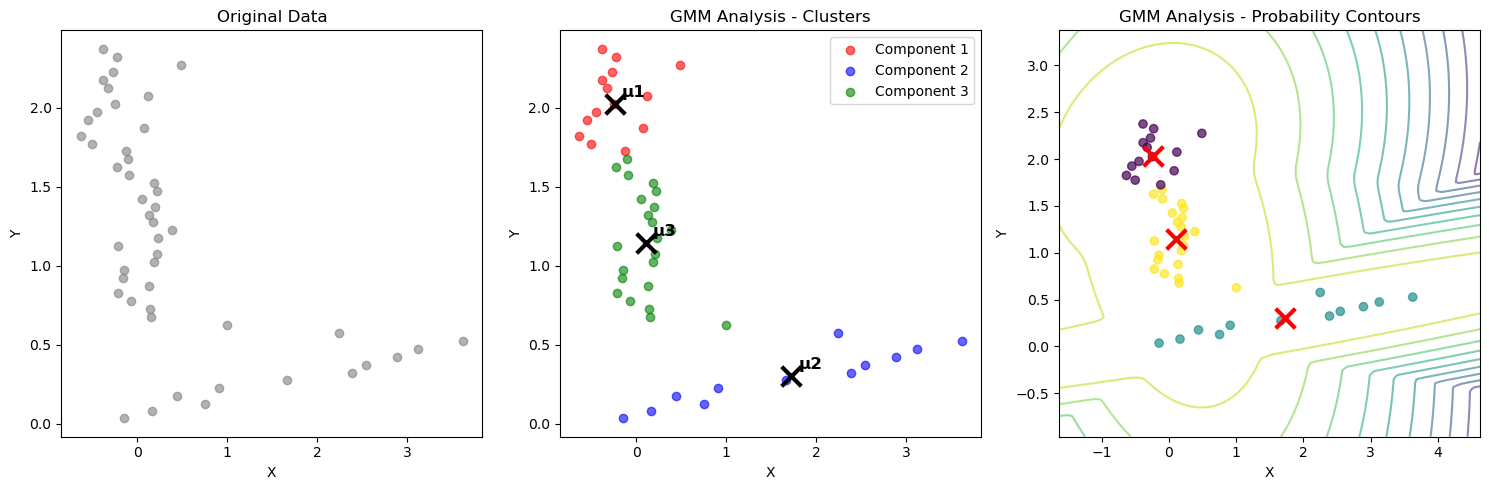

First 10 data points:
X		Y		Component	Probabilities
-0.145		0.035		1		[0.000	0.996	0.004]
0.165		0.078		1		[0.000	0.982	0.018]
0.753		0.127		1		[0.000	0.994	0.006]
0.440		0.176		1		[0.000	0.958	0.042]
0.911		0.225		1		[0.000	0.997	0.003]
1.664		0.274		1		[0.000	1.000	0.000]
2.387		0.324		1		[0.000	1.000	0.000]
2.547		0.373		1		[0.000	1.000	0.000]
2.891		0.423		1		[0.000	1.000	0.000]
3.126		0.474		1		[0.000	1.000	0.000]


In [73]:
# Generate sample data - two 1D arrays
X = np.array(nz[0])  # Replace with your actual X array
Y = zval
print("Example with your X and Y arrays:")
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print()

# Find optimal number of components
optimal_aic, optimal_bic = find_optimal_components(X, Y, max_components=8)

# Fit GMM with optimal number of components
results = fit_gmm(X, Y, n_components=3)  # Using 3 since we know the true number

# Print summary
print_gmm_summary(results)

# Plot results
plot_gmm_results(X, Y, results, "GMM Analysis")

# Show component assignments
print("First 10 data points:")
print("X\t\tY\t\tComponent\tProbabilities")
for i in range(10):
    probs = results['probabilities'][i]
    prob_str = "\t".join([f"{p:.3f}" for p in probs])
    print(f"{X[i]:.3f}\t\t{Y[i]:.3f}\t\t{results['labels'][i]}\t\t[{prob_str}]")

In [63]:
dir(xdgmm)

['V',
 '_EMstep',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_validate_data',
 '_validate_params',
 'alpha',
 'fit',
 'get_metadata_routing',
 'get_params',
 'logL',
 'logprob_a',
 'max_iter',
 'mu',
 'n_components',
 'random_state',
 'sample',
 'set_fit_re